# Importing the Data
### CelebA Dataset 

We will be utilizing the CelebA dataset for this exploration \
Pixels values will be normalized from [0,255] -> [-1, 1] \
This is done to work in conjunction with the Generator's tanh activation output \

In [1]:
import torchvision.transforms as transforms

# mean and std of channels
mean = [0.5, 0.5, 0.5] # [R,G,B]
std = [0.5, 0.5, 0.5] # [R,G,B]

transform = transforms.Compose([
    transforms.CenterCrop((178, 178)),
    transforms.Resize((64, 64)),
    transforms.ToTensor(), # pixel values go from [0,255] to [0,1]
    transforms.Normalize(
        mean=mean,
        std=std
    ) # pixel values go from [0,1] to [-1,1]
])

In [2]:
from torchvision.datasets import CelebA
from torch.utils.data import DataLoader

BATCH_SIZE = 64

train_dataset = CelebA(root='data', split='train', transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)


# Defining the Model

### Generator : 
Input: a latent z of dimension noise_dim (assume gaussian distribution) \
Output : A proposed image

### Discriminator
Input: a proposed image, namely the output G(z) \
Output : A binary classification label 
* '1' : The discriminator predicts that the image comes from distribution pdata (image is part of training set) 
* '0' : The dicrimimator predicts that the image comes from distribution pG (image was generated by Generator) 

### Goal 
The minimax game has achieved optimality when: 

$pG(x) = pData(x)$ (Optimal generator for optimal D) \
$DG(x) = \frac{pdata(x)}{pdata(x) + pG(x)} = 0.5$ (Discriminator is guessing)

In [3]:
import torch.nn as nn 

LATENT_DIM = 100

class Generator(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, img_height=64, img_width=64, img_channels=3):
        super().__init__()
        self.latent_dim = latent_dim
        self.model = nn.Sequential(
            nn.Linear(self.latent_dim, 256), 
            nn.BatchNorm1d(256),
            nn.ReLU(), 

            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            # Flatten to image dimensions
            # Tanh b/c pixel values are normalized between -1 and 1
            nn.Linear(512, img_height * img_width * img_channels),
            nn.Tanh(), # values \in [-1, 1]

            # [B, H * W * C] -> [B, C, H, W]
            nn.Unflatten(-1, (img_channels, img_height, img_width))
        )

    def forward(self, z):
        x = self.model(z)
        return x

In [ ]:
import torch.nn as nn

class Discriminator(nn.Module):
    def __init__(self, img_height=64, img_width=64, img_channels=3):
        super().__init__()

        # P(Y=1|x) = D(x) = sigmoid(f(x))
        # we will use BCEWithLogitsLoss below, because it is more numerically stable than using a plain Sigmoid followed by a BCELoss
        self.model = nn.Sequential(
            nn.Flatten(start_dim=1), 

            nn.Linear(img_height * img_width * img_channels, 512), 
            nn.BatchNorm1d(512),
            nn.ReLU(),

            nn.Linear(512, 1),
        )

    def forward(self, x):
        y = self.model(x)
        return y

In [5]:
from pathlib import Path
import matplotlib.pyplot as plt

def generate_and_save_images(model, epoch, noise):
    Path("./data/generated-images").mkdir(parents=True, exist_ok=True)

    model.eval()
    with torch.no_grad():
        fake_images = model(noise).cpu() # [-1, 1]
        fake_images = (fake_images.clamp(-1, 1) + 1) / 2 # [0, 1]

        fig = plt.figure(figsize = (4,4))
        for i in range(fake_images.size(0)):
            plt.subplot(4, 4, i + 1)

            image = fake_images[i].permute(1,2,0) # [C, H, W] -> [H, W, C]
            plt.imshow(image)
            plt.axis('off')

        plt.savefig(f"./data/generated-images/image_at_epoch_{epoch+1:04d}.png")
        plt.show()
        
    model.train()

In [6]:
import torch

def train_gan(generator,
              discriminator,
              generator_optimizer, 
              discriminator_optimizer, 
              train_loader, 
              device, 
              latent_dim=100, 
              num_epochs=50, 
              loss_function=nn.BCEWithLogitsLoss(), 
              fixed_noise=None,
              ):
    for epoch in range(num_epochs):
        for i, data in enumerate(train_loader):
            real_images, _ = data
            real_images = real_images.to(device)

            # ------  train discriminator on real data ------
            discriminator_optimizer.zero_grad()                        # zero out the gradients from the previous batch
            real_labels = torch.ones(real_images.size(0), 1, device=device) # (B, 1) -> '1' for each image in the batch
            real_outputs = discriminator(real_images)
            real_loss = loss_function(real_outputs, real_labels)
            real_loss.backward()                                       # computes weight updates for real images

            # ------ train discriminator on fake data ------
            z = torch.randn(real_images.size(0), latent_dim, device=device)
            fake_images = generator(z)
            fake_labels = torch.zeros(real_images.size(0), 1, device=device) # (B, 1) -> '0' for every img in the batch
            fake_outputs = discriminator(fake_images.detach())          # detach does not propagate gradients back through G
            fake_loss = loss_function(fake_outputs, fake_labels)
            fake_loss.backward()
            discriminator_optimizer.step()

            # ------ train the generator on the real data ------
            generator_optimizer.zero_grad()
            fake_labels = torch.ones(real_images.size(0), 1, device=device)  # # (B, 1) -> '1' for each image in the batch
            fake_outputs = discriminator(fake_images)                   # D(G(z))
            gen_loss = loss_function(fake_outputs, fake_labels)         # BCE(D(G(z)), 1) : B/C generator ideally wants to fool discriminator
            gen_loss.backward()
            generator_optimizer.step()

            if i % 100 == 0:
                print(f"Epoch [{epoch+1} / {num_epochs}], Step [{i + 1} / {len(train_loader)}] ,"
                      f"Discriminator Loss : {real_loss.item() + fake_loss.item():.4f}"
                      f"Generator Loss : {gen_loss.item():.4f}")
                
        if fixed_noise is not None:
            generate_and_save_images(generator, epoch, fixed_noise)


Epoch [1 / 50], Step [1 / 2544] ,Discriminator Loss : 1.4161Generator Loss : 0.7787
Epoch [1 / 50], Step [101 / 2544] ,Discriminator Loss : 1.1620Generator Loss : 0.9636
Epoch [1 / 50], Step [201 / 2544] ,Discriminator Loss : 0.6814Generator Loss : 1.5907
Epoch [1 / 50], Step [301 / 2544] ,Discriminator Loss : 0.3864Generator Loss : 2.3877
Epoch [1 / 50], Step [401 / 2544] ,Discriminator Loss : 0.2070Generator Loss : 3.2840
Epoch [1 / 50], Step [501 / 2544] ,Discriminator Loss : 0.1393Generator Loss : 3.7054
Epoch [1 / 50], Step [601 / 2544] ,Discriminator Loss : 0.0614Generator Loss : 5.0109
Epoch [1 / 50], Step [701 / 2544] ,Discriminator Loss : 0.0897Generator Loss : 4.9842
Epoch [1 / 50], Step [801 / 2544] ,Discriminator Loss : 0.0747Generator Loss : 5.1099
Epoch [1 / 50], Step [901 / 2544] ,Discriminator Loss : 0.1443Generator Loss : 4.7899
Epoch [1 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.2044Generator Loss : 6.7298
Epoch [1 / 50], Step [1101 / 2544] ,Discriminator Loss 

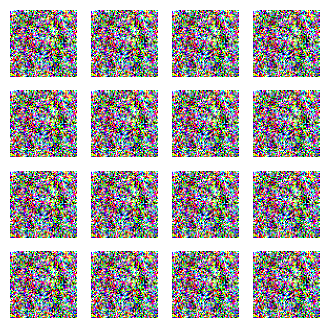

Epoch [2 / 50], Step [1 / 2544] ,Discriminator Loss : 0.0016Generator Loss : 7.5611
Epoch [2 / 50], Step [101 / 2544] ,Discriminator Loss : 0.0014Generator Loss : 7.8714
Epoch [2 / 50], Step [201 / 2544] ,Discriminator Loss : 0.0208Generator Loss : 6.3194
Epoch [2 / 50], Step [301 / 2544] ,Discriminator Loss : 0.0053Generator Loss : 6.7550
Epoch [2 / 50], Step [401 / 2544] ,Discriminator Loss : 0.0047Generator Loss : 6.1383
Epoch [2 / 50], Step [501 / 2544] ,Discriminator Loss : 0.0042Generator Loss : 6.5684
Epoch [2 / 50], Step [601 / 2544] ,Discriminator Loss : 0.0025Generator Loss : 7.1827
Epoch [2 / 50], Step [701 / 2544] ,Discriminator Loss : 0.0035Generator Loss : 7.2315
Epoch [2 / 50], Step [801 / 2544] ,Discriminator Loss : 0.0066Generator Loss : 7.2712
Epoch [2 / 50], Step [901 / 2544] ,Discriminator Loss : 0.0242Generator Loss : 6.6529
Epoch [2 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.0350Generator Loss : 5.0737
Epoch [2 / 50], Step [1101 / 2544] ,Discriminator Loss 

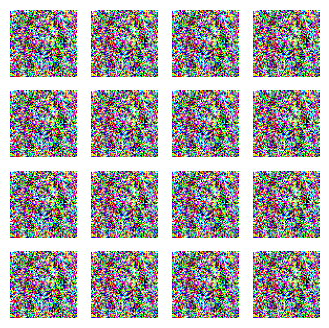

Epoch [3 / 50], Step [1 / 2544] ,Discriminator Loss : 0.0021Generator Loss : 6.7910
Epoch [3 / 50], Step [101 / 2544] ,Discriminator Loss : 0.0019Generator Loss : 6.8066
Epoch [3 / 50], Step [201 / 2544] ,Discriminator Loss : 0.0016Generator Loss : 7.2205
Epoch [3 / 50], Step [301 / 2544] ,Discriminator Loss : 0.0016Generator Loss : 7.3435
Epoch [3 / 50], Step [401 / 2544] ,Discriminator Loss : 0.0011Generator Loss : 7.3411
Epoch [3 / 50], Step [501 / 2544] ,Discriminator Loss : 0.0021Generator Loss : 7.2973
Epoch [3 / 50], Step [601 / 2544] ,Discriminator Loss : 0.0027Generator Loss : 7.1531
Epoch [3 / 50], Step [701 / 2544] ,Discriminator Loss : 0.0021Generator Loss : 7.6517
Epoch [3 / 50], Step [801 / 2544] ,Discriminator Loss : 0.0148Generator Loss : 6.8946
Epoch [3 / 50], Step [901 / 2544] ,Discriminator Loss : 0.0024Generator Loss : 7.0052
Epoch [3 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.0017Generator Loss : 8.3817
Epoch [3 / 50], Step [1101 / 2544] ,Discriminator Loss 

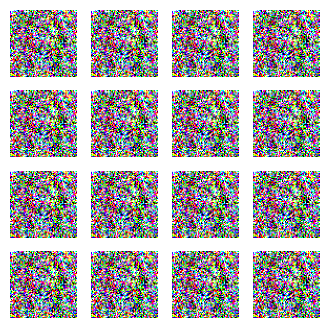

Epoch [4 / 50], Step [1 / 2544] ,Discriminator Loss : 0.0008Generator Loss : 7.6596
Epoch [4 / 50], Step [101 / 2544] ,Discriminator Loss : 0.0082Generator Loss : 7.3312
Epoch [4 / 50], Step [201 / 2544] ,Discriminator Loss : 0.0020Generator Loss : 8.2718
Epoch [4 / 50], Step [301 / 2544] ,Discriminator Loss : 0.0027Generator Loss : 8.5010
Epoch [4 / 50], Step [401 / 2544] ,Discriminator Loss : 0.0017Generator Loss : 6.8717
Epoch [4 / 50], Step [501 / 2544] ,Discriminator Loss : 0.0014Generator Loss : 7.1297
Epoch [4 / 50], Step [601 / 2544] ,Discriminator Loss : 0.0021Generator Loss : 7.0953
Epoch [4 / 50], Step [701 / 2544] ,Discriminator Loss : 0.0010Generator Loss : 7.3197
Epoch [4 / 50], Step [801 / 2544] ,Discriminator Loss : 0.0008Generator Loss : 7.5829
Epoch [4 / 50], Step [901 / 2544] ,Discriminator Loss : 0.0017Generator Loss : 8.0533
Epoch [4 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.0005Generator Loss : 7.8726
Epoch [4 / 50], Step [1101 / 2544] ,Discriminator Loss 

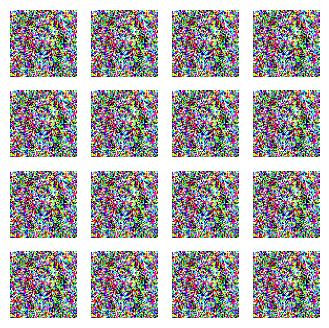

Epoch [5 / 50], Step [1 / 2544] ,Discriminator Loss : 0.0002Generator Loss : 9.1556
Epoch [5 / 50], Step [101 / 2544] ,Discriminator Loss : 0.0004Generator Loss : 9.1092
Epoch [5 / 50], Step [201 / 2544] ,Discriminator Loss : 0.0002Generator Loss : 9.0579
Epoch [5 / 50], Step [301 / 2544] ,Discriminator Loss : 0.0002Generator Loss : 9.0779
Epoch [5 / 50], Step [401 / 2544] ,Discriminator Loss : 0.0002Generator Loss : 9.1983
Epoch [5 / 50], Step [501 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 9.3024
Epoch [5 / 50], Step [601 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 9.3191
Epoch [5 / 50], Step [701 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 9.3104
Epoch [5 / 50], Step [801 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 9.5427
Epoch [5 / 50], Step [901 / 2544] ,Discriminator Loss : 0.0002Generator Loss : 9.4922
Epoch [5 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 9.4604
Epoch [5 / 50], Step [1101 / 2544] ,Discriminator Loss 

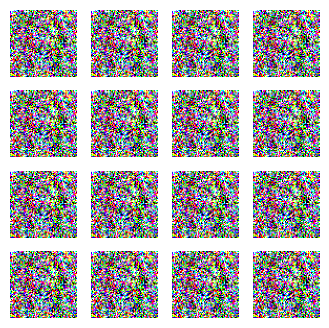

Epoch [6 / 50], Step [1 / 2544] ,Discriminator Loss : 0.0006Generator Loss : 8.0646
Epoch [6 / 50], Step [101 / 2544] ,Discriminator Loss : 0.0007Generator Loss : 8.3503
Epoch [6 / 50], Step [201 / 2544] ,Discriminator Loss : 0.0004Generator Loss : 8.3136
Epoch [6 / 50], Step [301 / 2544] ,Discriminator Loss : 0.0005Generator Loss : 8.8435
Epoch [6 / 50], Step [401 / 2544] ,Discriminator Loss : 0.0019Generator Loss : 10.0138
Epoch [6 / 50], Step [501 / 2544] ,Discriminator Loss : 0.0007Generator Loss : 9.2348
Epoch [6 / 50], Step [601 / 2544] ,Discriminator Loss : 0.0002Generator Loss : 9.2518
Epoch [6 / 50], Step [701 / 2544] ,Discriminator Loss : 0.0004Generator Loss : 9.2311
Epoch [6 / 50], Step [801 / 2544] ,Discriminator Loss : 0.0003Generator Loss : 9.1390
Epoch [6 / 50], Step [901 / 2544] ,Discriminator Loss : 0.0006Generator Loss : 8.9852
Epoch [6 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.0003Generator Loss : 9.1025
Epoch [6 / 50], Step [1101 / 2544] ,Discriminator Loss

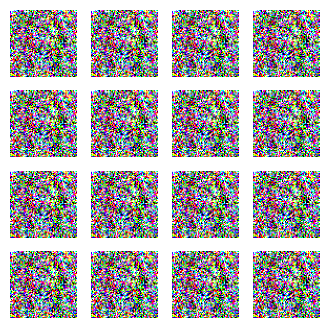

Epoch [7 / 50], Step [1 / 2544] ,Discriminator Loss : 0.0003Generator Loss : 10.0905
Epoch [7 / 50], Step [101 / 2544] ,Discriminator Loss : 0.0005Generator Loss : 10.2248
Epoch [7 / 50], Step [201 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 11.5253
Epoch [7 / 50], Step [301 / 2544] ,Discriminator Loss : 0.0003Generator Loss : 10.6802
Epoch [7 / 50], Step [401 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 9.6040
Epoch [7 / 50], Step [501 / 2544] ,Discriminator Loss : 0.0003Generator Loss : 9.4994
Epoch [7 / 50], Step [601 / 2544] ,Discriminator Loss : 0.0042Generator Loss : 6.9764
Epoch [7 / 50], Step [701 / 2544] ,Discriminator Loss : 0.0013Generator Loss : 7.5256
Epoch [7 / 50], Step [801 / 2544] ,Discriminator Loss : 0.0009Generator Loss : 7.9309
Epoch [7 / 50], Step [901 / 2544] ,Discriminator Loss : 0.0050Generator Loss : 9.0901
Epoch [7 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.0027Generator Loss : 8.1136
Epoch [7 / 50], Step [1101 / 2544] ,Discriminator L

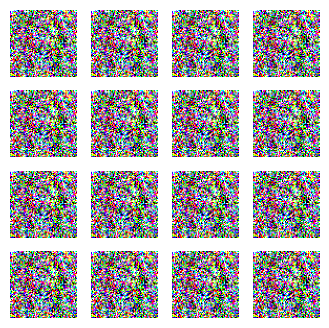

Epoch [8 / 50], Step [1 / 2544] ,Discriminator Loss : 0.0005Generator Loss : 11.0549
Epoch [8 / 50], Step [101 / 2544] ,Discriminator Loss : 0.0010Generator Loss : 9.0404
Epoch [8 / 50], Step [201 / 2544] ,Discriminator Loss : 0.0004Generator Loss : 8.7889
Epoch [8 / 50], Step [301 / 2544] ,Discriminator Loss : 0.0003Generator Loss : 9.0835
Epoch [8 / 50], Step [401 / 2544] ,Discriminator Loss : 0.0004Generator Loss : 9.7363
Epoch [8 / 50], Step [501 / 2544] ,Discriminator Loss : 0.0006Generator Loss : 8.4304
Epoch [8 / 50], Step [601 / 2544] ,Discriminator Loss : 0.0007Generator Loss : 8.4681
Epoch [8 / 50], Step [701 / 2544] ,Discriminator Loss : 0.0008Generator Loss : 8.2158
Epoch [8 / 50], Step [801 / 2544] ,Discriminator Loss : 0.0006Generator Loss : 8.3550
Epoch [8 / 50], Step [901 / 2544] ,Discriminator Loss : 0.0006Generator Loss : 8.7521
Epoch [8 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.0003Generator Loss : 9.1419
Epoch [8 / 50], Step [1101 / 2544] ,Discriminator Loss

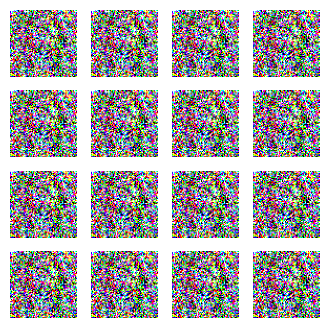

Epoch [9 / 50], Step [1 / 2544] ,Discriminator Loss : 0.0002Generator Loss : 9.2661
Epoch [9 / 50], Step [101 / 2544] ,Discriminator Loss : 0.0002Generator Loss : 9.9056
Epoch [9 / 50], Step [201 / 2544] ,Discriminator Loss : 0.0002Generator Loss : 9.1713
Epoch [9 / 50], Step [301 / 2544] ,Discriminator Loss : 0.0003Generator Loss : 9.3892
Epoch [9 / 50], Step [401 / 2544] ,Discriminator Loss : 0.0002Generator Loss : 9.0285
Epoch [9 / 50], Step [501 / 2544] ,Discriminator Loss : 0.0011Generator Loss : 11.4618
Epoch [9 / 50], Step [601 / 2544] ,Discriminator Loss : 0.0004Generator Loss : 10.1672
Epoch [9 / 50], Step [701 / 2544] ,Discriminator Loss : 0.0003Generator Loss : 9.8983
Epoch [9 / 50], Step [801 / 2544] ,Discriminator Loss : 0.0004Generator Loss : 9.8148
Epoch [9 / 50], Step [901 / 2544] ,Discriminator Loss : 0.0002Generator Loss : 9.8575
Epoch [9 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.0004Generator Loss : 9.9858
Epoch [9 / 50], Step [1101 / 2544] ,Discriminator Los

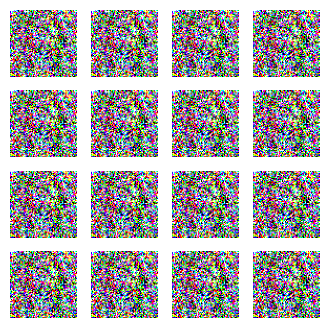

Epoch [10 / 50], Step [1 / 2544] ,Discriminator Loss : 0.0005Generator Loss : 10.1017
Epoch [10 / 50], Step [101 / 2544] ,Discriminator Loss : 0.0002Generator Loss : 10.2307
Epoch [10 / 50], Step [201 / 2544] ,Discriminator Loss : 0.0002Generator Loss : 10.1092
Epoch [10 / 50], Step [301 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 9.9529
Epoch [10 / 50], Step [401 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 10.1873
Epoch [10 / 50], Step [501 / 2544] ,Discriminator Loss : 0.0003Generator Loss : 10.3539
Epoch [10 / 50], Step [601 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 9.8798
Epoch [10 / 50], Step [701 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 9.5619
Epoch [10 / 50], Step [801 / 2544] ,Discriminator Loss : 0.0010Generator Loss : 8.5809
Epoch [10 / 50], Step [901 / 2544] ,Discriminator Loss : 0.0003Generator Loss : 9.3370
Epoch [10 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.0013Generator Loss : 10.5392
Epoch [10 / 50], Step [1101 / 2544] ,D

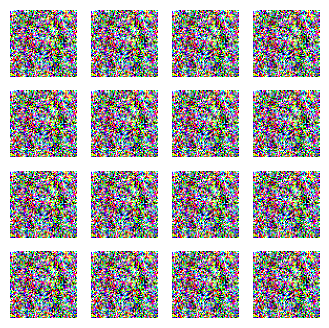

Epoch [11 / 50], Step [1 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 9.9794
Epoch [11 / 50], Step [101 / 2544] ,Discriminator Loss : 0.0002Generator Loss : 9.4367
Epoch [11 / 50], Step [201 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 9.6511
Epoch [11 / 50], Step [301 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 9.5635
Epoch [11 / 50], Step [401 / 2544] ,Discriminator Loss : 0.0003Generator Loss : 9.3839
Epoch [11 / 50], Step [501 / 2544] ,Discriminator Loss : 0.0005Generator Loss : 8.3284
Epoch [11 / 50], Step [601 / 2544] ,Discriminator Loss : 0.0009Generator Loss : 9.5447
Epoch [11 / 50], Step [701 / 2544] ,Discriminator Loss : 0.0004Generator Loss : 9.5106
Epoch [11 / 50], Step [801 / 2544] ,Discriminator Loss : 0.0013Generator Loss : 9.1937
Epoch [11 / 50], Step [901 / 2544] ,Discriminator Loss : 0.0003Generator Loss : 9.1624
Epoch [11 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.0006Generator Loss : 9.2664
Epoch [11 / 50], Step [1101 / 2544] ,Discrim

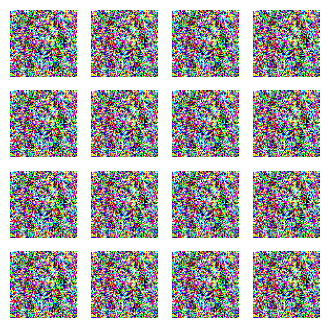

Epoch [12 / 50], Step [1 / 2544] ,Discriminator Loss : 0.0002Generator Loss : 9.1265
Epoch [12 / 50], Step [101 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 9.1074
Epoch [12 / 50], Step [201 / 2544] ,Discriminator Loss : 0.0002Generator Loss : 9.1666
Epoch [12 / 50], Step [301 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 9.2312
Epoch [12 / 50], Step [401 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 9.2914
Epoch [12 / 50], Step [501 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 9.3563
Epoch [12 / 50], Step [601 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 9.5749
Epoch [12 / 50], Step [701 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 9.5550
Epoch [12 / 50], Step [801 / 2544] ,Discriminator Loss : 0.0002Generator Loss : 10.0663
Epoch [12 / 50], Step [901 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 9.8950
Epoch [12 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 9.8135
Epoch [12 / 50], Step [1101 / 2544] ,Discri

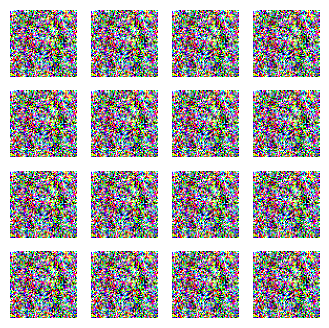

Epoch [13 / 50], Step [1 / 2544] ,Discriminator Loss : 0.0002Generator Loss : 9.4990
Epoch [13 / 50], Step [101 / 2544] ,Discriminator Loss : 0.0002Generator Loss : 9.4013
Epoch [13 / 50], Step [201 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 9.6723
Epoch [13 / 50], Step [301 / 2544] ,Discriminator Loss : 0.0002Generator Loss : 9.9362
Epoch [13 / 50], Step [401 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 9.9886
Epoch [13 / 50], Step [501 / 2544] ,Discriminator Loss : 0.0002Generator Loss : 10.0407
Epoch [13 / 50], Step [601 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 9.9902
Epoch [13 / 50], Step [701 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 10.1250
Epoch [13 / 50], Step [801 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 9.5129
Epoch [13 / 50], Step [901 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 9.5408
Epoch [13 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 9.5885
Epoch [13 / 50], Step [1101 / 2544] ,Discr

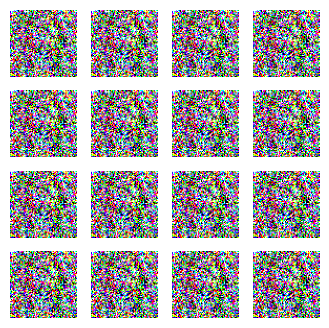

Epoch [14 / 50], Step [1 / 2544] ,Discriminator Loss : 0.0004Generator Loss : 10.3397
Epoch [14 / 50], Step [101 / 2544] ,Discriminator Loss : 0.0003Generator Loss : 9.3305
Epoch [14 / 50], Step [201 / 2544] ,Discriminator Loss : 0.0002Generator Loss : 11.5228
Epoch [14 / 50], Step [301 / 2544] ,Discriminator Loss : 0.0002Generator Loss : 11.4640
Epoch [14 / 50], Step [401 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 10.8618
Epoch [14 / 50], Step [501 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 11.2076
Epoch [14 / 50], Step [601 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 11.0590
Epoch [14 / 50], Step [701 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 10.8312
Epoch [14 / 50], Step [801 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 11.1737
Epoch [14 / 50], Step [901 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 10.8212
Epoch [14 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 11.0188
Epoch [14 / 50], Step [1101 / 2544

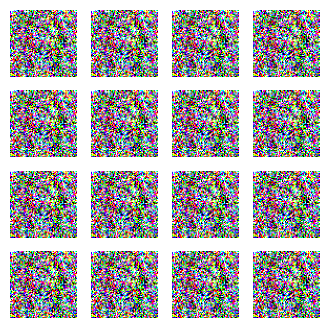

Epoch [15 / 50], Step [1 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 10.1791
Epoch [15 / 50], Step [101 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 10.1575
Epoch [15 / 50], Step [201 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 10.1932
Epoch [15 / 50], Step [301 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 10.2348
Epoch [15 / 50], Step [401 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 10.2813
Epoch [15 / 50], Step [501 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 10.3359
Epoch [15 / 50], Step [601 / 2544] ,Discriminator Loss : 0.0012Generator Loss : 8.1415
Epoch [15 / 50], Step [701 / 2544] ,Discriminator Loss : 0.0003Generator Loss : 8.3498
Epoch [15 / 50], Step [801 / 2544] ,Discriminator Loss : 0.0002Generator Loss : 8.6339
Epoch [15 / 50], Step [901 / 2544] ,Discriminator Loss : 0.0002Generator Loss : 8.8463
Epoch [15 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.0002Generator Loss : 9.0264
Epoch [15 / 50], Step [1101 / 2544] ,D

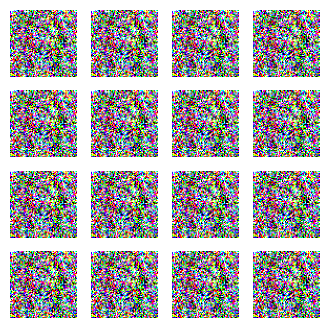

Epoch [16 / 50], Step [1 / 2544] ,Discriminator Loss : 0.0002Generator Loss : 11.7000
Epoch [16 / 50], Step [101 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 11.3214
Epoch [16 / 50], Step [201 / 2544] ,Discriminator Loss : 0.0000Generator Loss : 11.2701
Epoch [16 / 50], Step [301 / 2544] ,Discriminator Loss : 0.0000Generator Loss : 11.2336
Epoch [16 / 50], Step [401 / 2544] ,Discriminator Loss : 0.0000Generator Loss : 11.1980
Epoch [16 / 50], Step [501 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 11.1650
Epoch [16 / 50], Step [601 / 2544] ,Discriminator Loss : 0.0000Generator Loss : 11.1389
Epoch [16 / 50], Step [701 / 2544] ,Discriminator Loss : 0.0000Generator Loss : 11.1044
Epoch [16 / 50], Step [801 / 2544] ,Discriminator Loss : 0.0000Generator Loss : 11.0804
Epoch [16 / 50], Step [901 / 2544] ,Discriminator Loss : 0.0000Generator Loss : 11.0591
Epoch [16 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.0000Generator Loss : 11.0394
Epoch [16 / 50], Step [1101 / 254

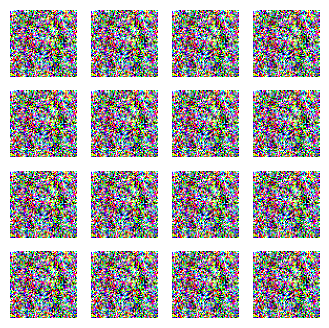

Epoch [17 / 50], Step [1 / 2544] ,Discriminator Loss : 0.0002Generator Loss : 11.5473
Epoch [17 / 50], Step [101 / 2544] ,Discriminator Loss : 0.0002Generator Loss : 11.3524
Epoch [17 / 50], Step [201 / 2544] ,Discriminator Loss : 0.0004Generator Loss : 11.1895
Epoch [17 / 50], Step [301 / 2544] ,Discriminator Loss : 0.0003Generator Loss : 11.3762
Epoch [17 / 50], Step [401 / 2544] ,Discriminator Loss : 0.0003Generator Loss : 10.2775
Epoch [17 / 50], Step [501 / 2544] ,Discriminator Loss : 0.0003Generator Loss : 10.9139
Epoch [17 / 50], Step [601 / 2544] ,Discriminator Loss : 0.0002Generator Loss : 11.0759
Epoch [17 / 50], Step [701 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 11.2243
Epoch [17 / 50], Step [801 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 11.4924
Epoch [17 / 50], Step [901 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 11.4487
Epoch [17 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.0002Generator Loss : 11.5457
Epoch [17 / 50], Step [1101 / 254

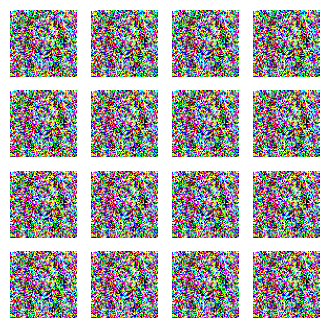

Epoch [18 / 50], Step [1 / 2544] ,Discriminator Loss : 0.0003Generator Loss : 10.5915
Epoch [18 / 50], Step [101 / 2544] ,Discriminator Loss : 0.0041Generator Loss : 10.3102
Epoch [18 / 50], Step [201 / 2544] ,Discriminator Loss : 0.0022Generator Loss : 11.0814
Epoch [18 / 50], Step [301 / 2544] ,Discriminator Loss : 0.0022Generator Loss : 9.3007
Epoch [18 / 50], Step [401 / 2544] ,Discriminator Loss : 0.0020Generator Loss : 10.1012
Epoch [18 / 50], Step [501 / 2544] ,Discriminator Loss : 0.0003Generator Loss : 11.0404
Epoch [18 / 50], Step [601 / 2544] ,Discriminator Loss : 0.0006Generator Loss : 11.3545
Epoch [18 / 50], Step [701 / 2544] ,Discriminator Loss : 0.0006Generator Loss : 11.2458
Epoch [18 / 50], Step [801 / 2544] ,Discriminator Loss : 0.0008Generator Loss : 11.7524
Epoch [18 / 50], Step [901 / 2544] ,Discriminator Loss : 0.0004Generator Loss : 12.7544
Epoch [18 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.0006Generator Loss : 13.2042
Epoch [18 / 50], Step [1101 / 2544

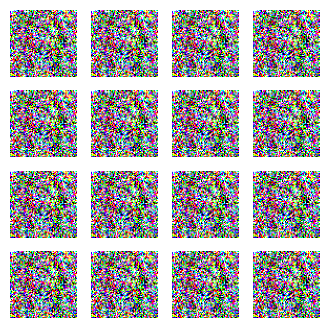

Epoch [19 / 50], Step [1 / 2544] ,Discriminator Loss : 0.0002Generator Loss : 9.5335
Epoch [19 / 50], Step [101 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 9.4837
Epoch [19 / 50], Step [201 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 9.5942
Epoch [19 / 50], Step [301 / 2544] ,Discriminator Loss : 0.0002Generator Loss : 9.5510
Epoch [19 / 50], Step [401 / 2544] ,Discriminator Loss : 0.0003Generator Loss : 9.6768
Epoch [19 / 50], Step [501 / 2544] ,Discriminator Loss : 0.0002Generator Loss : 9.5744
Epoch [19 / 50], Step [601 / 2544] ,Discriminator Loss : 0.0002Generator Loss : 9.5289
Epoch [19 / 50], Step [701 / 2544] ,Discriminator Loss : 0.0003Generator Loss : 9.4943
Epoch [19 / 50], Step [801 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 9.4780
Epoch [19 / 50], Step [901 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 9.4979
Epoch [19 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 9.5176
Epoch [19 / 50], Step [1101 / 2544] ,Discrim

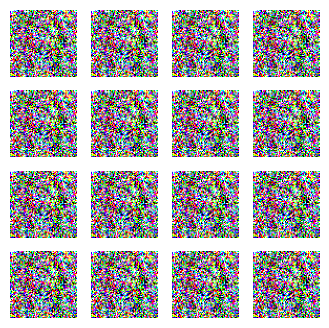

Epoch [20 / 50], Step [1 / 2544] ,Discriminator Loss : 0.0002Generator Loss : 9.9296
Epoch [20 / 50], Step [101 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 9.0648
Epoch [20 / 50], Step [201 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 9.4081
Epoch [20 / 50], Step [301 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 9.6726
Epoch [20 / 50], Step [401 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 9.7670
Epoch [20 / 50], Step [501 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 9.8898
Epoch [20 / 50], Step [601 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 9.9748
Epoch [20 / 50], Step [701 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 10.0574
Epoch [20 / 50], Step [801 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 10.1339
Epoch [20 / 50], Step [901 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 10.5822
Epoch [20 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.0003Generator Loss : 10.7668
Epoch [20 / 50], Step [1101 / 2544] ,Dis

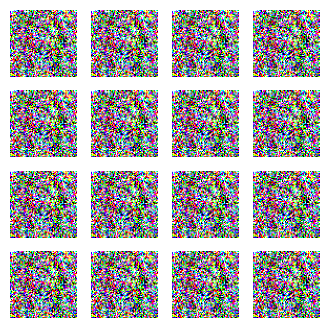

Epoch [21 / 50], Step [1 / 2544] ,Discriminator Loss : 0.0003Generator Loss : 9.3288
Epoch [21 / 50], Step [101 / 2544] ,Discriminator Loss : 0.0002Generator Loss : 9.7477
Epoch [21 / 50], Step [201 / 2544] ,Discriminator Loss : 0.0004Generator Loss : 9.8666
Epoch [21 / 50], Step [301 / 2544] ,Discriminator Loss : 0.0002Generator Loss : 10.0256
Epoch [21 / 50], Step [401 / 2544] ,Discriminator Loss : 0.0002Generator Loss : 9.7191
Epoch [21 / 50], Step [501 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 10.5029
Epoch [21 / 50], Step [601 / 2544] ,Discriminator Loss : 0.0002Generator Loss : 10.5299
Epoch [21 / 50], Step [701 / 2544] ,Discriminator Loss : 0.0004Generator Loss : 11.8264
Epoch [21 / 50], Step [801 / 2544] ,Discriminator Loss : 0.0005Generator Loss : 11.4535
Epoch [21 / 50], Step [901 / 2544] ,Discriminator Loss : 0.0003Generator Loss : 11.5021
Epoch [21 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.0002Generator Loss : 11.5876
Epoch [21 / 50], Step [1101 / 2544] ,

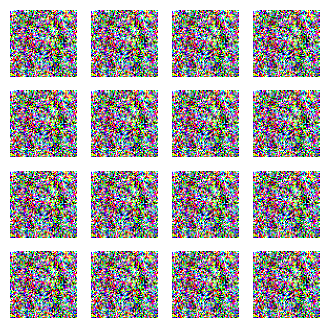

Epoch [22 / 50], Step [1 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 13.1388
Epoch [22 / 50], Step [101 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 13.1755
Epoch [22 / 50], Step [201 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 12.8331
Epoch [22 / 50], Step [301 / 2544] ,Discriminator Loss : 0.0024Generator Loss : 11.3142
Epoch [22 / 50], Step [401 / 2544] ,Discriminator Loss : 0.0201Generator Loss : 10.5883
Epoch [22 / 50], Step [501 / 2544] ,Discriminator Loss : 0.0053Generator Loss : 12.3974
Epoch [22 / 50], Step [601 / 2544] ,Discriminator Loss : 0.0002Generator Loss : 10.6705
Epoch [22 / 50], Step [701 / 2544] ,Discriminator Loss : 0.0004Generator Loss : 10.4901
Epoch [22 / 50], Step [801 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 11.3779
Epoch [22 / 50], Step [901 / 2544] ,Discriminator Loss : 0.0004Generator Loss : 10.4379
Epoch [22 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.0002Generator Loss : 10.2732
Epoch [22 / 50], Step [1101 / 254

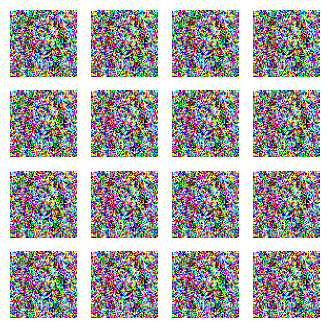

Epoch [23 / 50], Step [1 / 2544] ,Discriminator Loss : 0.0004Generator Loss : 10.2529
Epoch [23 / 50], Step [101 / 2544] ,Discriminator Loss : 0.0043Generator Loss : 10.9740
Epoch [23 / 50], Step [201 / 2544] ,Discriminator Loss : 0.0007Generator Loss : 11.7188
Epoch [23 / 50], Step [301 / 2544] ,Discriminator Loss : 0.0002Generator Loss : 13.0188
Epoch [23 / 50], Step [401 / 2544] ,Discriminator Loss : 0.0003Generator Loss : 12.0114
Epoch [23 / 50], Step [501 / 2544] ,Discriminator Loss : 0.0003Generator Loss : 11.9454
Epoch [23 / 50], Step [601 / 2544] ,Discriminator Loss : 0.0002Generator Loss : 10.2880
Epoch [23 / 50], Step [701 / 2544] ,Discriminator Loss : 0.0009Generator Loss : 12.1094
Epoch [23 / 50], Step [801 / 2544] ,Discriminator Loss : 0.0004Generator Loss : 10.7214
Epoch [23 / 50], Step [901 / 2544] ,Discriminator Loss : 0.0003Generator Loss : 10.3275
Epoch [23 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.0002Generator Loss : 10.2250
Epoch [23 / 50], Step [1101 / 254

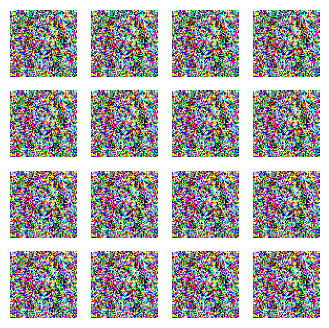

Epoch [24 / 50], Step [1 / 2544] ,Discriminator Loss : 0.0003Generator Loss : 10.4766
Epoch [24 / 50], Step [101 / 2544] ,Discriminator Loss : 0.0002Generator Loss : 11.0759
Epoch [24 / 50], Step [201 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 11.2560
Epoch [24 / 50], Step [301 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 11.4491
Epoch [24 / 50], Step [401 / 2544] ,Discriminator Loss : 0.0002Generator Loss : 10.9859
Epoch [24 / 50], Step [501 / 2544] ,Discriminator Loss : 0.0091Generator Loss : 12.2917
Epoch [24 / 50], Step [601 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 11.9571
Epoch [24 / 50], Step [701 / 2544] ,Discriminator Loss : 0.0006Generator Loss : 9.9828
Epoch [24 / 50], Step [801 / 2544] ,Discriminator Loss : 0.0004Generator Loss : 9.9288
Epoch [24 / 50], Step [901 / 2544] ,Discriminator Loss : 0.0006Generator Loss : 9.9864
Epoch [24 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 9.8757
Epoch [24 / 50], Step [1101 / 2544] ,

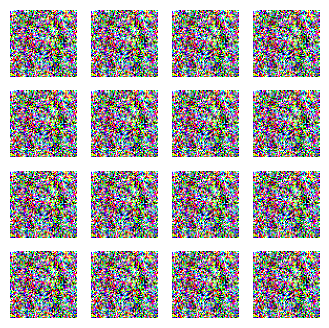

Epoch [25 / 50], Step [1 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 10.2294
Epoch [25 / 50], Step [101 / 2544] ,Discriminator Loss : 0.0000Generator Loss : 10.2801
Epoch [25 / 50], Step [201 / 2544] ,Discriminator Loss : 0.0000Generator Loss : 10.3314
Epoch [25 / 50], Step [301 / 2544] ,Discriminator Loss : 0.0000Generator Loss : 10.3868
Epoch [25 / 50], Step [401 / 2544] ,Discriminator Loss : 0.0000Generator Loss : 10.4356
Epoch [25 / 50], Step [501 / 2544] ,Discriminator Loss : 0.0000Generator Loss : 10.4800
Epoch [25 / 50], Step [601 / 2544] ,Discriminator Loss : 0.0000Generator Loss : 10.4986
Epoch [25 / 50], Step [701 / 2544] ,Discriminator Loss : 0.0000Generator Loss : 10.5598
Epoch [25 / 50], Step [801 / 2544] ,Discriminator Loss : 0.0000Generator Loss : 10.6066
Epoch [25 / 50], Step [901 / 2544] ,Discriminator Loss : 0.0000Generator Loss : 10.6654
Epoch [25 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 10.7128
Epoch [25 / 50], Step [1101 / 254

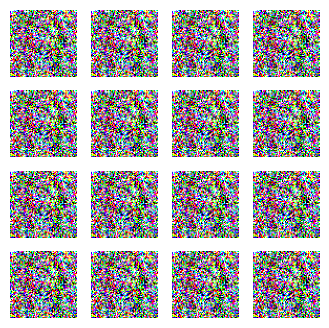

Epoch [26 / 50], Step [1 / 2544] ,Discriminator Loss : 0.0003Generator Loss : 10.6729
Epoch [26 / 50], Step [101 / 2544] ,Discriminator Loss : 0.0006Generator Loss : 11.4687
Epoch [26 / 50], Step [201 / 2544] ,Discriminator Loss : 0.0005Generator Loss : 11.8458
Epoch [26 / 50], Step [301 / 2544] ,Discriminator Loss : 0.0002Generator Loss : 12.8733
Epoch [26 / 50], Step [401 / 2544] ,Discriminator Loss : 0.0015Generator Loss : 12.5547
Epoch [26 / 50], Step [501 / 2544] ,Discriminator Loss : 0.0004Generator Loss : 11.7132
Epoch [26 / 50], Step [601 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 12.5431
Epoch [26 / 50], Step [701 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 12.4861
Epoch [26 / 50], Step [801 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 12.7936
Epoch [26 / 50], Step [901 / 2544] ,Discriminator Loss : 0.0002Generator Loss : 12.0092
Epoch [26 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 11.8896
Epoch [26 / 50], Step [1101 / 254

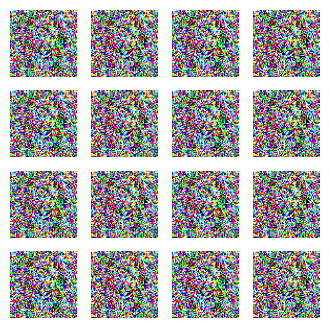

Epoch [27 / 50], Step [1 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 10.1827
Epoch [27 / 50], Step [101 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 10.1382
Epoch [27 / 50], Step [201 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 10.1410
Epoch [27 / 50], Step [301 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 10.2349
Epoch [27 / 50], Step [401 / 2544] ,Discriminator Loss : 0.0000Generator Loss : 10.2331
Epoch [27 / 50], Step [501 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 10.2637
Epoch [27 / 50], Step [601 / 2544] ,Discriminator Loss : 0.0000Generator Loss : 10.2864
Epoch [27 / 50], Step [701 / 2544] ,Discriminator Loss : 0.0000Generator Loss : 10.2720
Epoch [27 / 50], Step [801 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 10.3269
Epoch [27 / 50], Step [901 / 2544] ,Discriminator Loss : 0.0000Generator Loss : 10.3783
Epoch [27 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.0000Generator Loss : 10.9749
Epoch [27 / 50], Step [1101 / 254

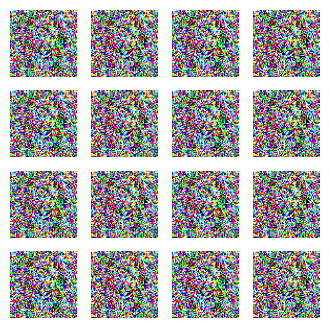

Epoch [28 / 50], Step [1 / 2544] ,Discriminator Loss : 0.0000Generator Loss : 10.9868
Epoch [28 / 50], Step [101 / 2544] ,Discriminator Loss : 0.0000Generator Loss : 11.0247
Epoch [28 / 50], Step [201 / 2544] ,Discriminator Loss : 0.0000Generator Loss : 11.0635
Epoch [28 / 50], Step [301 / 2544] ,Discriminator Loss : 0.0000Generator Loss : 11.1100
Epoch [28 / 50], Step [401 / 2544] ,Discriminator Loss : 0.0000Generator Loss : 11.1529
Epoch [28 / 50], Step [501 / 2544] ,Discriminator Loss : 0.0000Generator Loss : 11.1913
Epoch [28 / 50], Step [601 / 2544] ,Discriminator Loss : 0.0000Generator Loss : 11.2645
Epoch [28 / 50], Step [701 / 2544] ,Discriminator Loss : 0.0000Generator Loss : 11.4139
Epoch [28 / 50], Step [801 / 2544] ,Discriminator Loss : 0.0000Generator Loss : 11.4190
Epoch [28 / 50], Step [901 / 2544] ,Discriminator Loss : 0.0000Generator Loss : 11.4362
Epoch [28 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.0000Generator Loss : 11.4610
Epoch [28 / 50], Step [1101 / 254

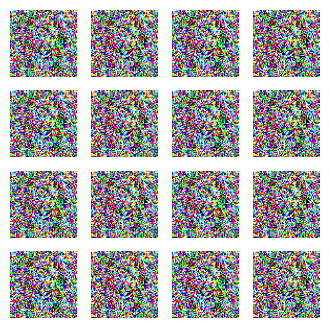

Epoch [29 / 50], Step [1 / 2544] ,Discriminator Loss : 0.0000Generator Loss : 12.3194
Epoch [29 / 50], Step [101 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 12.2510
Epoch [29 / 50], Step [201 / 2544] ,Discriminator Loss : 0.0000Generator Loss : 12.1782
Epoch [29 / 50], Step [301 / 2544] ,Discriminator Loss : 0.0000Generator Loss : 12.1496
Epoch [29 / 50], Step [401 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 12.1799
Epoch [29 / 50], Step [501 / 2544] ,Discriminator Loss : 0.0000Generator Loss : 12.1123
Epoch [29 / 50], Step [601 / 2544] ,Discriminator Loss : 0.0000Generator Loss : 12.0521
Epoch [29 / 50], Step [701 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 12.8668
Epoch [29 / 50], Step [801 / 2544] ,Discriminator Loss : 0.0004Generator Loss : 12.8466
Epoch [29 / 50], Step [901 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 12.6744
Epoch [29 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.0005Generator Loss : 12.5441
Epoch [29 / 50], Step [1101 / 254

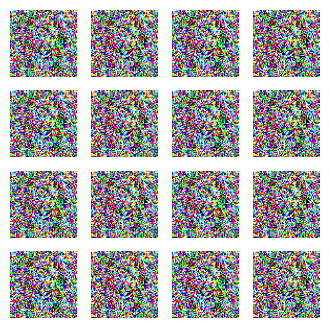

Epoch [30 / 50], Step [1 / 2544] ,Discriminator Loss : 0.0000Generator Loss : 11.9612
Epoch [30 / 50], Step [101 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 11.8899
Epoch [30 / 50], Step [201 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 11.8298
Epoch [30 / 50], Step [301 / 2544] ,Discriminator Loss : 0.0000Generator Loss : 11.7636
Epoch [30 / 50], Step [401 / 2544] ,Discriminator Loss : 0.0000Generator Loss : 11.7114
Epoch [30 / 50], Step [501 / 2544] ,Discriminator Loss : 0.0000Generator Loss : 11.6653
Epoch [30 / 50], Step [601 / 2544] ,Discriminator Loss : 0.0000Generator Loss : 11.6171
Epoch [30 / 50], Step [701 / 2544] ,Discriminator Loss : 0.0000Generator Loss : 11.5760
Epoch [30 / 50], Step [801 / 2544] ,Discriminator Loss : 0.0000Generator Loss : 11.5327
Epoch [30 / 50], Step [901 / 2544] ,Discriminator Loss : 0.0007Generator Loss : 9.7458
Epoch [30 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.0001Generator Loss : 12.4379
Epoch [30 / 50], Step [1101 / 2544

KeyboardInterrupt: 

In [7]:
NUM_EPOCHS = 50

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
generator = Generator(latent_dim=LATENT_DIM).to(device)
discriminator = Discriminator().to(device)

generator_optimizer = torch.optim.AdamW(generator.parameters())
discriminator_optimizer = torch.optim.AdamW(discriminator.parameters())

fixed_noise = torch.randn(16, LATENT_DIM, device=device)

train_gan(generator,
        discriminator,
        generator_optimizer, 
        discriminator_optimizer, 
        train_loader, 
        device, 
        latent_dim=100, 
        num_epochs=50, 
        loss_function=nn.BCEWithLogitsLoss(), 
        fixed_noise=fixed_noise
        )